In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch

In [3]:
torch.cuda.is_available()

True

In [4]:
device = "cuda"

(array([205., 203., 198., 198., 197., 219., 184., 203., 183., 197., 251.,
        211., 204., 194., 234., 181., 204., 185., 190., 192., 211., 201.,
        196., 214., 201., 202., 187., 183., 188., 209., 191., 225., 193.,
        200., 190., 179., 179., 198., 204., 199., 214., 191., 210., 214.,
        215., 217., 201., 205., 183., 167.]),
 array([1.96754932e-04, 2.01853756e-02, 4.01739962e-02, 6.01626188e-02,
        8.01512375e-02, 1.00139856e-01, 1.20128483e-01, 1.40117094e-01,
        1.60105720e-01, 1.80094346e-01, 2.00082958e-01, 2.20071584e-01,
        2.40060210e-01, 2.60048836e-01, 2.80037433e-01, 3.00026059e-01,
        3.20014685e-01, 3.40003312e-01, 3.59991938e-01, 3.79980534e-01,
        3.99969161e-01, 4.19957787e-01, 4.39946413e-01, 4.59935039e-01,
        4.79923666e-01, 4.99912262e-01, 5.19900918e-01, 5.39889514e-01,
        5.59878111e-01, 5.79866767e-01, 5.99855363e-01, 6.19844019e-01,
        6.39832616e-01, 6.59821212e-01, 6.79809868e-01, 6.99798465e-01,
        7.

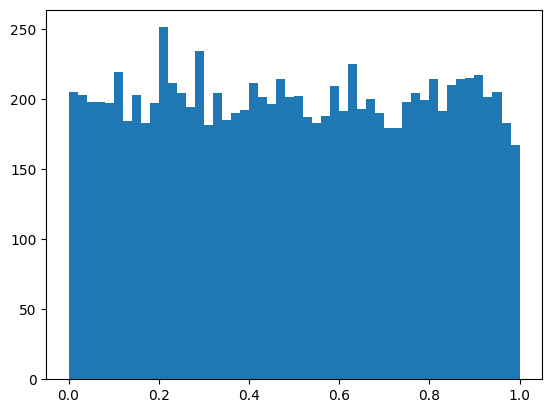

In [5]:
x = torch.rand(10000)
plt.hist(x, bins=50)

In [6]:
x.dtype

torch.float32

## Generating color dataset

In [89]:
colors_dict = {0: 'gray', 1: 'red', 2: 'green', 3: 'blue', 4: 'purple', 5: 'pink', 6: 'orange', 7: 'brown', 8: 'yellow', 9: 'cyan'}

In [ ]:
colors_data = []

In [33]:
def gen_color():
    rgb = torch.rand(3)
    plt.hist([1], color=rgb.tolist())
    plt.show()
    color_label = int(input('Enter the color: '))
    if color_label == -1:
        return -1
    colors_data.append((rgb, color_label))

In [44]:
#done = False
#while not done:
#    done = gen_color() == -1

In [35]:
len(colors_data)

148

In [37]:
xs, ys = [i[0] for i in colors_data], [i[1] for i in colors_data]

In [39]:
xs, ys = torch.stack(xs, dim=0), torch.tensor(ys)

In [40]:
xs.shape

torch.Size([148, 3])

In [1]:
ys.shape

NameError: name 'ys' is not defined

In [43]:
#torch.save(xs, 'xs.pt')
#torch.save(ys, 'ys.pt')

In [18]:
xs = torch.load('xs.pt')
ys = torch.load('ys.pt')

C:\Users\1111\AppData\Local\Temp\ipykernel_13420\317256814.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  xs = torch.load('xs.pt')
C:\Users\1111\AppData\Local\Temp\ipyk

In [19]:
xs.shape

torch.Size([148, 3])

In [20]:
ys.shape

torch.Size([148])

In [21]:
ys

tensor([7, 4, 3, 5, 3, 2, 3, 2, 2, 1, 8, 2, 2, 4, 2, 8, 2, 4, 2, 2, 5, 4, 8, 2,
        9, 4, 1, 3, 2, 3, 3, 4, 6, 9, 7, 2, 3, 2, 1, 1, 4, 3, 7, 5, 2, 2, 2, 7,
        3, 7, 3, 3, 2, 3, 2, 9, 3, 2, 4, 2, 4, 9, 7, 2, 7, 6, 5, 8, 4, 2, 7, 8,
        3, 5, 2, 5, 5, 3, 8, 5, 9, 2, 2, 9, 3, 8, 5, 6, 3, 7, 8, 7, 2, 4, 0, 8,
        6, 4, 5, 0, 2, 8, 2, 4, 3, 2, 9, 5, 4, 3, 7, 1, 5, 2, 3, 1, 2, 3, 9, 3,
        4, 2, 4, 3, 9, 2, 4, 9, 5, 5, 1, 8, 5, 2, 4, 1, 4, 3, 5, 3, 2, 2, 1, 3,
        6, 0, 3, 9])

## Defining ANN (single layer)
Input layer: 3 floats (RGB values)
- dim: batch x 3

Weights (converting RGB to color logits)
- dim: 3 x 10

Output layer: 10 floats (logits of each color)
- dim: batch x 10
- output = input @ weights

Actual probabilities: softmax(output), i.e. exp(output)/sum(output)
- dim: batch x 10

Loss: NLL, i.e. -probs[torch.arange(batch)][ys].log().mean()

Hyperparams: LR

In [66]:
W = torch.randn((3, 10), requires_grad=True)
W

tensor([[-0.1835,  0.8031,  0.1258,  0.3650, -0.8479, -2.3931, -0.6577,  0.0290,
         -1.1491, -0.7551],
        [-0.0112, -1.0370,  1.6758, -1.2186, -0.0544,  0.6570, -0.4330,  0.4082,
         -1.2758, -3.3750],
        [-0.0193, -1.6758,  0.4116, -0.3361,  0.5899, -0.5605, -0.6681,  0.5786,
         -0.9020,  0.2593]], requires_grad=True)

In [67]:
xs[:5]

tensor([[0.4307, 0.4282, 0.3119],
        [0.2797, 0.1685, 0.7059],
        [0.3004, 0.3376, 0.4670],
        [0.9527, 0.5826, 0.7408],
        [0.0284, 0.1196, 0.3129]])

In [68]:
xs[:5] @ W

tensor([[-8.9815e-02, -6.2093e-01,  9.0015e-01, -4.6947e-01, -2.0444e-01,
         -9.2409e-01, -6.7707e-01,  3.6776e-01, -1.3225e+00, -1.6895e+00],
        [-6.6814e-02, -1.1331e+00,  6.0807e-01, -3.4048e-01,  1.7011e-01,
         -9.5425e-01, -7.2852e-01,  4.8533e-01, -1.1730e+00, -5.9678e-01],
        [-6.7894e-02, -8.9153e-01,  7.9575e-01, -4.5872e-01,  2.4526e-03,
         -7.5880e-01, -6.5578e-01,  4.1674e-01, -1.1971e+00, -1.2451e+00],
        [-1.9558e-01, -1.0805e+00,  1.4010e+00, -6.1119e-01, -4.0245e-01,
         -2.3123e+00, -1.3738e+00,  6.9406e-01, -2.5061e+00, -2.4935e+00],
        [-1.2590e-02, -6.2553e-01,  3.3272e-01, -2.4048e-01,  1.5397e-01,
         -1.6486e-01, -2.7953e-01,  2.3068e-01, -4.6743e-01, -3.4384e-01]],
       grad_fn=<MmBackward0>)

In [69]:
(xs[:5] @ W).exp()

tensor([[0.9141, 0.5374, 2.4600, 0.6253, 0.8151, 0.3969, 0.5081, 1.4445, 0.2665,
         0.1846],
        [0.9354, 0.3220, 1.8369, 0.7114, 1.1854, 0.3851, 0.4826, 1.6247, 0.3094,
         0.5506],
        [0.9344, 0.4100, 2.2161, 0.6321, 1.0025, 0.4682, 0.5190, 1.5170, 0.3021,
         0.2879],
        [0.8224, 0.3394, 4.0593, 0.5427, 0.6687, 0.0990, 0.2532, 2.0018, 0.0816,
         0.0826],
        [0.9875, 0.5350, 1.3947, 0.7863, 1.1665, 0.8480, 0.7561, 1.2595, 0.6266,
         0.7090]], grad_fn=<ExpBackward0>)

In [70]:
(xs[:5] @ W).exp().sum(1, keepdims=True)

tensor([[8.1525],
        [8.3436],
        [8.2893],
        [8.9507],
        [9.0692]], grad_fn=<SumBackward1>)

In [71]:
(xs[:5] @ W).exp() / (xs[:5] @ W).exp().sum(1, keepdims=True)

tensor([[0.1121, 0.0659, 0.3017, 0.0767, 0.1000, 0.0487, 0.0623, 0.1772, 0.0327,
         0.0226],
        [0.1121, 0.0386, 0.2202, 0.0853, 0.1421, 0.0462, 0.0578, 0.1947, 0.0371,
         0.0660],
        [0.1127, 0.0495, 0.2673, 0.0763, 0.1209, 0.0565, 0.0626, 0.1830, 0.0364,
         0.0347],
        [0.0919, 0.0379, 0.4535, 0.0606, 0.0747, 0.0111, 0.0283, 0.2236, 0.0091,
         0.0092],
        [0.1089, 0.0590, 0.1538, 0.0867, 0.1286, 0.0935, 0.0834, 0.1389, 0.0691,
         0.0782]], grad_fn=<DivBackward0>)

In [72]:
((xs[:5] @ W).exp() / (xs[:5] @ W).exp().sum(1, keepdims=True))[torch.arange(5), torch.tensor([1, 2, 3, 4, 5])]

tensor([0.0659, 0.2202, 0.0763, 0.0747, 0.0935], grad_fn=<IndexBackward0>)

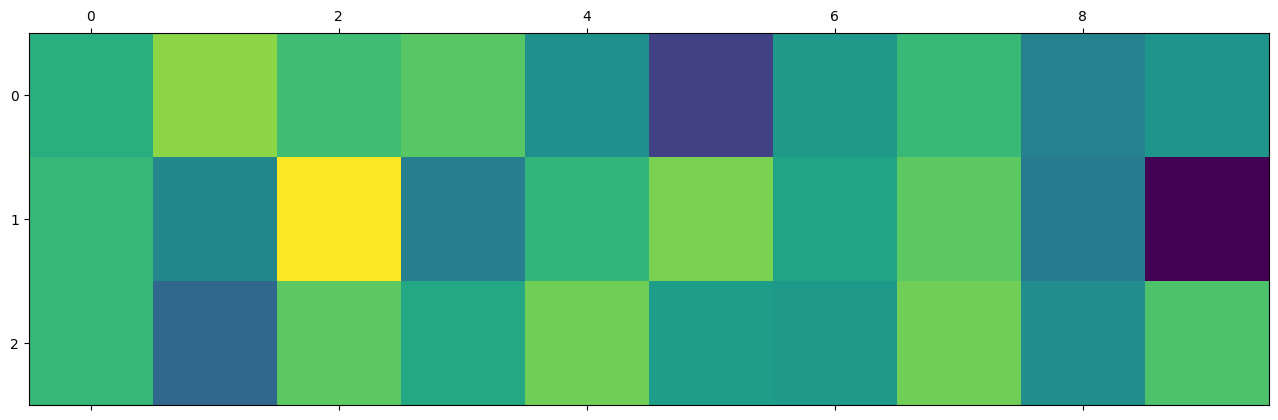

In [73]:
plt.matshow(W.detach().numpy())

## Training

In [74]:
xs_len = len(xs)
lr = 0.1
batch_size = 5
iters = 1000

In [124]:
for i in range(iters):
    # Select random batch of inputs & labels
    idxs = torch.randint(xs_len, (batch_size,))
    inputs = xs[idxs]
    labels = ys[idxs]
    # Forward pass
    logits = inputs @ W
    # Softmax
    logits_exp = logits.exp()
    outputs = logits_exp / logits_exp.sum(1, keepdims=True)
    # NLL loss
    relevant_probs = outputs[torch.arange(batch_size), labels]
    loss = -relevant_probs.log().mean()
    if i % 100 == 0:
        print(f'Iteration {i}, loss {loss:.4f}')

    # Backprop
    W.grad = None
    loss.backward()
    # Parameter update
    with torch.no_grad():
        W -= lr * W.grad

Iteration 0, loss 1.1739
Iteration 100, loss 1.7336
Iteration 200, loss 1.0977
Iteration 300, loss 1.5415
Iteration 400, loss 1.2998
Iteration 500, loss 1.1928
Iteration 600, loss 0.9973
Iteration 700, loss 0.5428
Iteration 800, loss 1.0050
Iteration 900, loss 0.8879


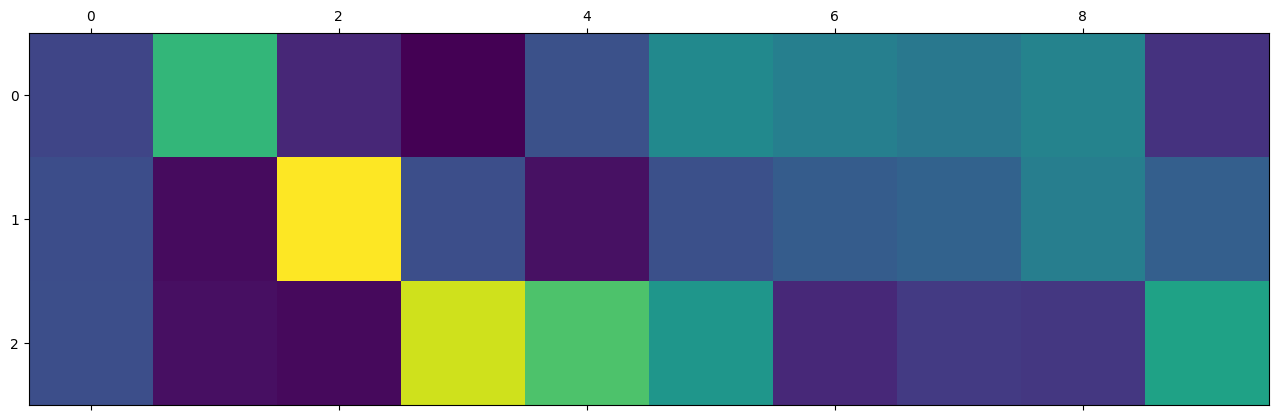

In [76]:
plt.matshow(W.detach().numpy())

## Prediction

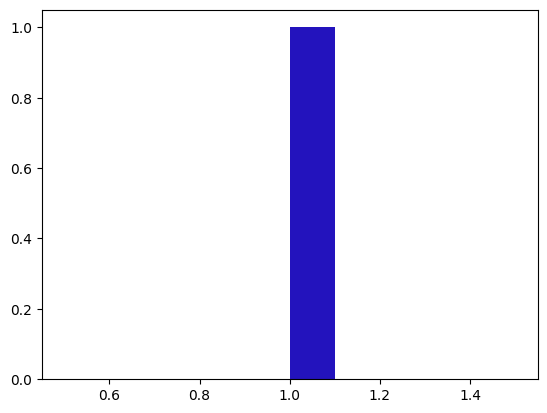

In [143]:
test_xs = torch.rand(3)
plt.hist([1], color=test_xs.tolist())
plt.show()
test_xs = torch.reshape(test_xs, (1, 3))

In [144]:
with torch.no_grad():
    # Forward pass
    logits = test_xs @ W
    # Softmax
    logits_exp = logits.exp()
    outputs = logits_exp / logits_exp.sum(1, keepdims=True)
    # Prediction
    print(outputs)
    for i in torch.argmax(outputs, 1):
        print(colors_dict[i.item()])

tensor([[0.0091, 0.0028, 0.0009, 0.5660, 0.3105, 0.0593, 0.0025, 0.0034, 0.0035,
         0.0419]])
blue
